### Introdução à Análise de Texto com Processamento de Linguagem Natural (NLP)

In [1]:
try:
    import pandas as pd
except ImportError as e:
    %pip install pandas
    import pandas as pd

In [2]:
try:
    import os
except ImportError as e:
    %pip install os
    import os

In [3]:
try:
    import sklearn
except ImportError as e:
    %pip install scikit-learn
    import sklearn

In [4]:
from sklearn.model_selection import train_test_split


In [5]:
from sklearn.linear_model import LogisticRegression

#### 1: Importando e visualizando inicialmente os dados

In [6]:
curr_dir = os.getcwd()
path = os.path.join(curr_dir, 'data', 'imdb-reviews-pt-br.csv')
resenhas = pd.read_csv(path)

In [7]:
resenhas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49459 entries, 0 to 49458
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         49459 non-null  int64 
 1   text_en    49459 non-null  object
 2   text_pt    49459 non-null  object
 3   sentiment  49459 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


In [8]:
resenhas.head()

,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg


In [9]:
resenhas

,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg
...,...,...,...,...
49454,49456,"Seeing as the vote average was pretty low, and...","Como a média de votos era muito baixa, e o fat...",pos
49455,49457,"The plot had some wretched, unbelievable twist...",O enredo teve algumas reviravoltas infelizes e...,pos
49456,49458,I am amazed at how this movieand most others h...,Estou espantado com a forma como este filme e ...,pos
49457,49459,A Christmas Together actually came before my t...,A Christmas Together realmente veio antes do m...,pos


Aqui, tentamos treinar um modelo de regressão com base nos dados que tínhamos. Isso não dá certo, porém, pois os dados estão em linguagem natural. É necessário que os passemos para uma representação entendível para o algoritmo (0 para negativo e 1 para positivo)

In [10]:
treino, teste, label_treino, label_teste = train_test_split(resenhas.text_pt,
                                                              resenhas.sentiment,
                                                              random_state= 42)

In [11]:
regressao_logistica = LogisticRegression()
#regressao_logistica.fit(treino, label_treino)
#acuracia = regressao_logistica.score(teste, label_teste)
#print(acuracia)

# o comando acima dá erro, pois os dados são strings e o modelo de regressão logística só aceita números. 
# para resolver isso, precisamos transformar os textos em números, utilizando uma técnica chamada "bag of words".

> Regressão logística/logistic regression: técnica de classificação binária, será utilizada aqui para mapear as previsões em 0 e 1 (análise negativa e positiva)

#### 2: Explorando o dataset

In [12]:
resenhas.shape

(49459, 4)

In [13]:
# exemplo de mensagem negativa de treino
print("Negativa: \n")
print(resenhas.text_pt[220])

Negativa: 

Um dos piores filmes que eu já vi! Depois de assistir eu saio como, o que aconteceu? Estou confuso até hoje, alguém pode me explicar esse filme, por favor? tanto a qualidade de atuação quanto a de imagem são tão ruins que você pensa que está assistindo a um projeto escolar de alguém feito com uma câmera de vídeo caseira. Primeiro, eu não posso acreditar que como algumas pessoas poderiam dar 10 estrelas para este filme. Porque, seu filme incrivelmente ruim! Este filme não é assustador em tudo! Também não há clichês de terror típicos. O enredo e atuação deste filme foi terrível. Não é fantástico, surrealista ou de terror, é apenas um filme cinematográfico turco horrivelmente ruim. E, finalmente, houve muitas cenas desnecessárias e personagens desnecessários. Quando eu assisto Gomeda eu caí em tão desesperado, tão triste para o jovem cineasta turco.Por favor, por favor, não faça cinema assim!


In [14]:
# exemplo de mensagem positiva de treino
print("Positiva: \n")
print(resenhas.text_pt[42500])

Positiva: 

Comecei a assistir a um replay desse filme de TV em uma tarde de domingo, pensando que era apenas mais um filme de desastre de avião idiota. Eu estava errado. "Pandora Clock" é um thriller político inteligente que está muito além da qualidade da maioria dos filmes de TV. Poderia facilmente ter feito sua estréia na telona. O elenco é excelente, incluindo os veteranos Richard Dean Anderson, Edward Herrmann, Robert Guillaume e Robert Loggia. Daphne Zuniga faz um de seus melhores desempenhos como especialista médica trabalhando para a CIA, e Frasiers Jane Leeves também é muito boa. O diálogo é bem escrito e a história é convincente por toda parte. Na verdade, a hora final é tão cheia de reviravoltas e suspense que você não pode deixar seu lugar por um segundo. Se você tiver a chance de ver esse filme, invista o tempo - quase quatro horas. Você será ricamente recompensado!


In [15]:
print(resenhas.sentiment.value_counts()) # ignorando a divisão teste e treino, pois estou olhando se o dataset completo está balanceado ou não

sentiment
neg    24765
pos    24694
Name: count, dtype: int64


In [16]:
# como é mais comum utilizar 0 e 1 para a classificação binária/regressão logística, adiciono essa coluna no dataframe
classificacao = resenhas['sentiment'].replace(['neg', 'pos'], [0, 1])
classificacao

C:\Users\noteb\AppData\Local\Temp\ipykernel_15436\3977780138.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  classificacao = resenhas['sentiment'].replace(['neg', 'pos'], [0, 1])


0        0
1        0
2        0
3        0
4        0
        ..
49454    1
49455    1
49456    1
49457    1
49458    1
Name: sentiment, Length: 49459, dtype: int64

In [17]:
resenhas['classificacao'] = classificacao
resenhas.head()

,id,text_en,text_pt,sentiment,classificacao
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,0
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,0
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,0
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,0
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,0


In [18]:
resenhas.tail()

,id,text_en,text_pt,sentiment,classificacao
49454,49456,"Seeing as the vote average was pretty low, and...","Como a média de votos era muito baixa, e o fat...",pos,1
49455,49457,"The plot had some wretched, unbelievable twist...",O enredo teve algumas reviravoltas infelizes e...,pos,1
49456,49458,I am amazed at how this movieand most others h...,Estou espantado com a forma como este filme e ...,pos,1
49457,49459,A Christmas Together actually came before my t...,A Christmas Together realmente veio antes do m...,pos,1
49458,49460,Working-class romantic drama from director Mar...,O drama romântico da classe trabalhadora do di...,pos,1


Neste primeiro momento, iremos utilizar a representação bag of words para representar as palavras em um vetor 

#### 3: Tokenização, visualização e limpeza dos dados

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

texto = ["Assisti um filme ótimo", "Assisti um filme ruim"]

vetorizar = CountVectorizer(lowercase=False)
bag_of_words = vetorizar.fit_transform(texto) # fit transform é utilizado para "treinar" o count vectorizer
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 5)>

In [20]:
vocabulario = vetorizar.get_feature_names_out() # para ver todas as palavras salvas

In [21]:
matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns=vocabulario) # utilizo a estrutura de dados para matrizes esparsas para criar um dataframe eficiente no uso da memória

In [22]:
matriz_esparsa

,Assisti,filme,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


Aplicando a representação bag of words nos dados reais do IMDb

In [23]:
vetorizar = CountVectorizer(lowercase=False, max_features=100) # iremos limitar o número de palavras/tokens únicos aos 50 mais comuns
bag_of_words = vetorizar.fit_transform(resenhas.text_pt) # iremos utilizar os dados em português
print(bag_of_words.shape) # resposta original: (49459, 156923)

(49459, 100)


Utilizo a representação bag of words dos dados para realizar a regressão logística (como agora os dados são numéricos, não dá erro) 

In [24]:
treino, teste, label_treino, label_teste = train_test_split(bag_of_words,
                                                            resenhas.classificacao,
                                                            random_state= 42)

regressao_logistica = LogisticRegression()
regressao_logistica.fit(treino, label_treino)
acuracia = regressao_logistica.score(teste, label_teste)
print(acuracia)

0.7014961585119288


In [25]:
def classificar_texto(texto, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False, max_features=50)
    bag_of_words = vetorizar.fit_transform(texto[coluna_texto])

    treino, teste, label_treino, label_teste = train_test_split(bag_of_words,
                                                            texto[coluna_classificacao],
                                                            random_state= 42)
    
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(treino, label_treino)
    acuracia = regressao_logistica.score(teste, label_teste)
    return acuracia

print(classificar_texto(resenhas, 'text_pt', 'classificacao'))

0.6583097452486858


Utilizamos a visualização de nuvem de palavras e gráfico de barras para identificarmos a ococrrência de stop words e removê-las

In [26]:
try:
    import wordcloud
except ImportError as e:
    %pip install wordcloud
    import wordcloud


In [27]:
from wordcloud import WordCloud

todas_palavras = ' '.join([texto for texto in resenhas.text_pt]) # junto todas as palavras em uma única string para criar a wordcloud
print(f"Total de caracteres na string: {len(todas_palavras)}")

nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110,
                           collocations=False).generate(todas_palavras) # collocations = False garante que apareca as palavras em si, não os bigramas (padrão de duas palavras seguidas)

Total de caracteres na string: 63448424


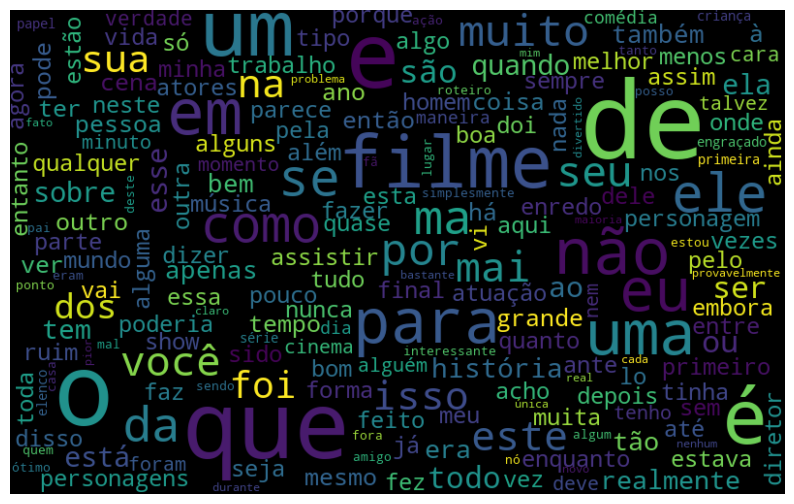

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.imshow(nuvem_palavras, interpolation='bilinear')
plt.axis("off")
plt.show()

Faço uma nova nuvem de palavras para identificar melhor quais são as que mais aparecem negativa e positivamente

In [29]:
def nuvem_palavras_neg(texto, coluna_texto):
    texto_negativo = texto.query("sentiment == 'neg'")

    todas_palavras = ' '.join([texto for texto in texto_negativo[coluna_texto]]) 
    nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110,
                            collocations=False).generate(todas_palavras)
    
    plt.figure(figsize=(10, 7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis("off")
    plt.show()


In [30]:
def nuvem_palavras_pos(texto, coluna_texto):
    texto_positivo = texto.query("sentiment == 'pos'")

    todas_palavras = ' '.join([texto for texto in texto_positivo[coluna_texto]]) 
    nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110,
                            collocations=False).generate(todas_palavras)
    
    plt.figure(figsize=(10, 7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis("off")
    plt.show()

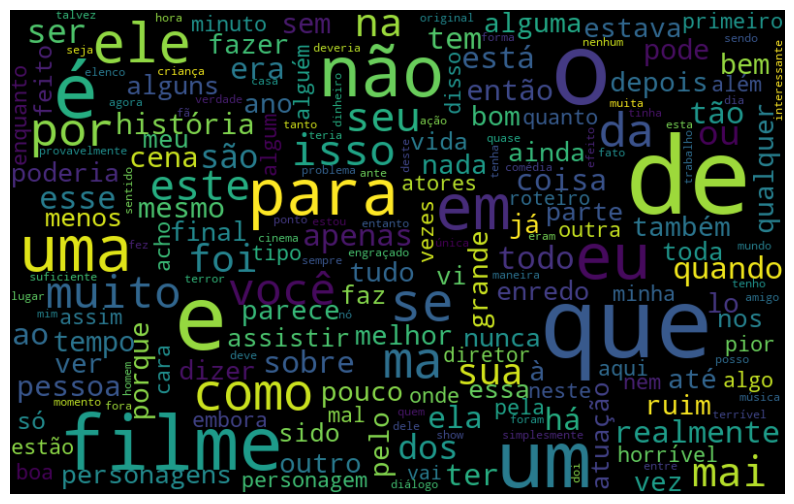

In [31]:
nuvem_palavras_neg(resenhas, "text_pt")

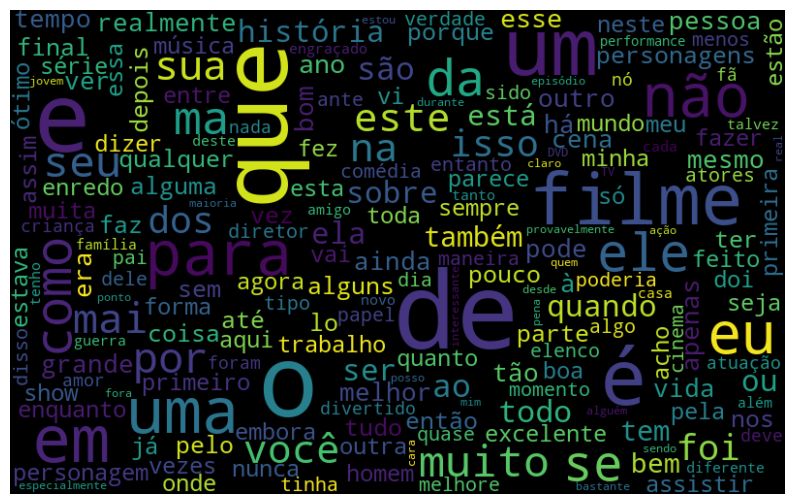

In [32]:
nuvem_palavras_pos(resenhas, "text_pt")

Utilizaremos a biblioteca NLTK para separar as frases em tokens e conseguir um dicionário de frequência das palavras do dataset

In [33]:
try:
    import nltk
except ImportError as e:
    %pip install nltk
    import nltk

nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[

True

In [34]:
import nltk
frase = ["um filme bom", "um filme ruim", "um filme ótimo", "um filme péssimo"]
frequencia = nltk.FreqDist(frase)
frequencia

FreqDist({'um filme bom': 1, 'um filme ruim': 1, 'um filme ótimo': 1, 'um filme péssimo': 1})

In [35]:
from nltk import tokenize

frase = "Bem vindo ao mundo do PLN!"
token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)

In [36]:
print(token_frase)

['Bem', 'vindo', 'ao', 'mundo', 'do', 'PLN!']


In [37]:
token_frase = token_espaco.tokenize(todas_palavras) # separando as frases do dataset por tokens
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'de': 417651, 'que': 325070, 'e': 299743, 'o': 244881, 'um': 216410, 'a': 210179, 'é': 192381, 'em': 132778, 'uma': 130888, 'não': 127915, ...})

In [38]:
# crio um dataframe com as informações de palavras e frequências providas pela função freqdist
df_frequencia = pd.DataFrame(
    {"Palavra": list(frequencia.keys()),
     "Frequência": list(frequencia.values())}
)

In [39]:
df_frequencia.nlargest(columns= "Frequência", n = 10)

,Palavra,Frequência
20,de,417651
14,que,325070
42,e,299743
3,o,244881
7,um,216410
102,a,210179
45,é,192381
200,em,132778
1,uma,130888
29,não,127915


In [40]:
try:
    import seaborn as sns
except ImportError:
    %pip install seaborn
    import seaborn as sns

# identificando as palavras mais frequentes do dataset e plotando um gráfico de barras
def grafico_barras(texto, coluna_texto, quantidade):
    todas_palavras = ' '.join([texto for texto in texto[coluna_texto]])

    token_frase = token_espaco.tokenize(todas_palavras) # separando as frases do dataset por tokens
    frequencia = nltk.FreqDist(token_frase)
    
    df_frequencia = pd.DataFrame(
    {"Palavra": list(frequencia.keys()),
     "Frequência": list(frequencia.values())}
    )

    plt.figure(figsize=(12, 8))
    ax = sns.barplot(data = df_frequencia.nlargest(columns= "Frequência", n = quantidade), x = "Palavra", y = "Frequência", color = 'gray')
    ax.set(ylabel = "Contagem")
    plt.show()

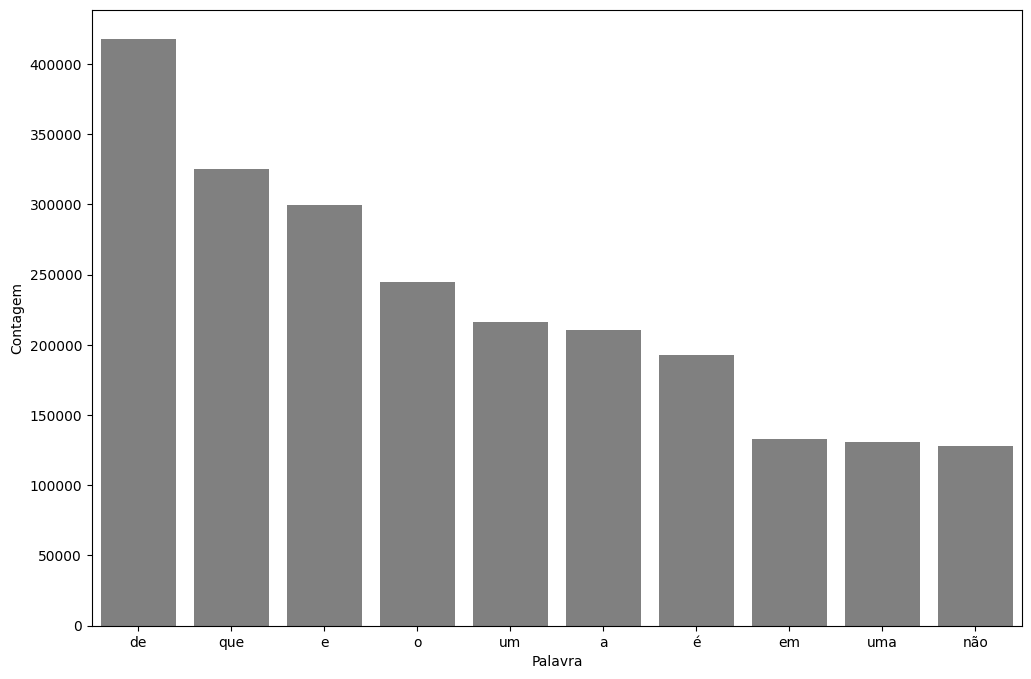

In [41]:
grafico_barras(resenhas, 'text_pt', 10)

Atualmente, as palavras mais frequentes são stopwords. Iremos utilizar a biblioteca NLTK para importar um lista dessas expressões e removê-las do banco de dados

In [42]:
palavras_irrelevantes = nltk.corpus.stopwords.words("portuguese")
print(palavras_irrelevantes)

['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'éramos', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estar', 'estas', 'estava', 'estavam', 'estávamos', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estivéramos', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'fôramos', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'há', 'haja', 'hajam', 'hajamos', 'hão', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houverá', 'houveram', 'houvéramos', 'houverão', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houveríamos', 'houvermos', 'houvesse', 'houvessem', 'houvésse

In [43]:
frase_processada = list()

for opiniao in resenhas.text_pt:
    nova_frase = list()
    palavras_texto = token_espaco.tokenize(opiniao) # separando a frase palavra por palavra

    for palavra in palavras_texto:
        if palavra not in palavras_irrelevantes:
            nova_frase.append(palavra)

    frase_processada.append(' '.join(nova_frase)) # juntando as palavras processadas em uma única lista/string

resenhas["tratamento_stopwords"] = frase_processada

In [44]:
resenhas.head()

,id,text_en,text_pt,sentiment,classificacao,tratamento_stopwords
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,0,"Mais vez, Sr. Costner arrumou filme tempo nece..."
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,0,Este exemplo motivo maioria filmes ação mesmos...
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,0,"Primeiro tudo odeio raps imbecis, poderiam agi..."
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,0,Nem Beatles puderam escrever músicas todos gos...
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,0,"Filmes fotos latão palavra apropriada eles, ve..."


In [45]:
classificar_texto(resenhas, 'tratamento_stopwords', 'classificacao') # usando a função criada anteriormente para treinar o modelo com os dados pré-processados

0.6810351799433886

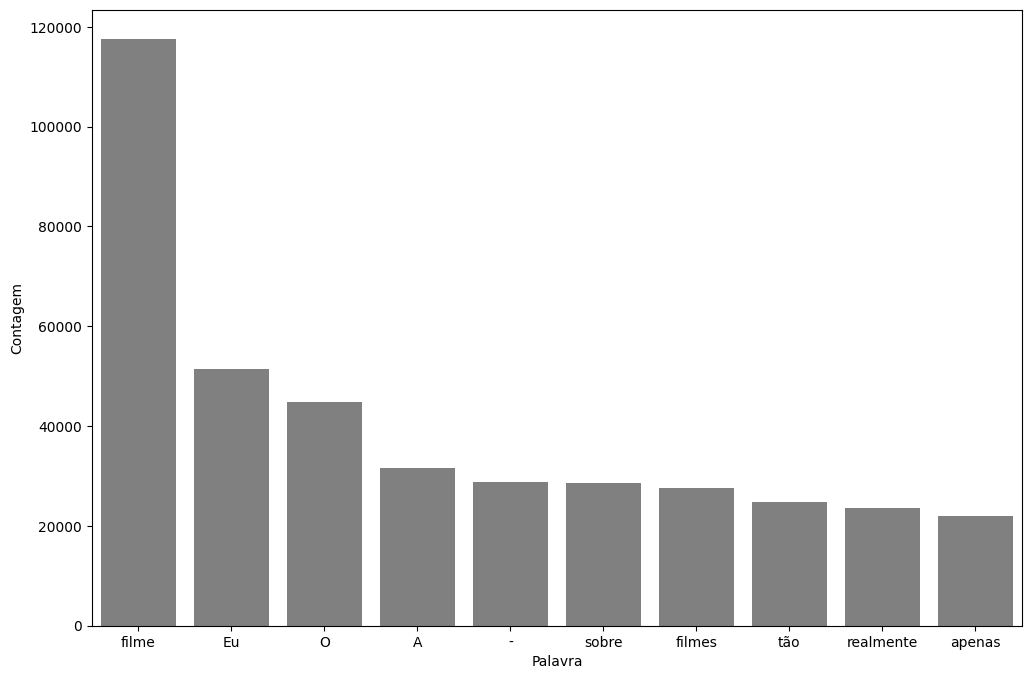

In [46]:
grafico_barras(resenhas, 'tratamento_stopwords', 10)

#### 4: Melhorando a tokenização 

In [47]:
from string import punctuation
from nltk import tokenize

pontuacao = list(punctuation)

stopwords_e_pontuacao = palavras_irrelevantes + pontuacao

token_pontuacao = tokenize.WordPunctTokenizer() # as palavras serão separadas por pontuação, para que duas palavras iguais não sejam tratadas como diferentes por conta de sinais irrelevantes na análise de sentimento

In [48]:
frase_processada = list()
for opiniao in resenhas.tratamento_stopwords:
    nova_frase = list()
    palavras_texto = token_pontuacao.tokenize(opiniao) # separando a frase em palavras ignorando a pontuação
    for palavra in palavras_texto:
        if palavra not in stopwords_e_pontuacao:
            nova_frase.append(palavra)
    
    frase_processada.append(' '.join(nova_frase))

resenhas["tratamento_stopwords_pontuacao"] = frase_processada

In [49]:
resenhas.head(10)

,id,text_en,text_pt,sentiment,classificacao,tratamento_stopwords,tratamento_stopwords_pontuacao
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,0,"Mais vez, Sr. Costner arrumou filme tempo nece...",Mais vez Sr Costner arrumou filme tempo necess...
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,0,Este exemplo motivo maioria filmes ação mesmos...,Este exemplo motivo maioria filmes ação mesmos...
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,0,"Primeiro tudo odeio raps imbecis, poderiam agi...",Primeiro tudo odeio raps imbecis poderiam agir...
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,0,Nem Beatles puderam escrever músicas todos gos...,Nem Beatles puderam escrever músicas todos gos...
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,0,"Filmes fotos latão palavra apropriada eles, ve...",Filmes fotos latão palavra apropriada verdade ...
5,6,"A funny thing happened to me while watching ""M...",Uma coisa engraçada aconteceu comigo enquanto ...,neg,0,Uma coisa engraçada aconteceu comigo enquanto ...,Uma coisa engraçada aconteceu comigo enquanto ...
6,7,This German horror film has to be one of the w...,Este filme de terror alemão tem que ser um dos...,neg,0,Este filme terror alemão estranhos vi. Eu cien...,Este filme terror alemão estranhos vi Eu cient...
7,8,"Being a long-time fan of Japanese film, I expe...","Sendo um fã de longa data do cinema japonês, e...",neg,0,"Sendo fã longa data cinema japonês, esperava i...",Sendo fã longa data cinema japonês esperava Eu...
8,9,"""Tokyo Eyes"" tells of a 17 year old Japanese g...","""Tokyo Eyes"" fala de uma menina japonesa de 17...",neg,0,"""Tokyo Eyes"" fala menina japonesa 17 anos cai ...",Tokyo Eyes fala menina japonesa 17 anos cai ho...
9,10,Wealthy horse ranchers in Buenos Aires have a ...,Fazendeiros ricos em Buenos Aires têm uma long...,neg,0,Fazendeiros ricos Buenos Aires têm longa polít...,Fazendeiros ricos Buenos Aires têm longa polít...


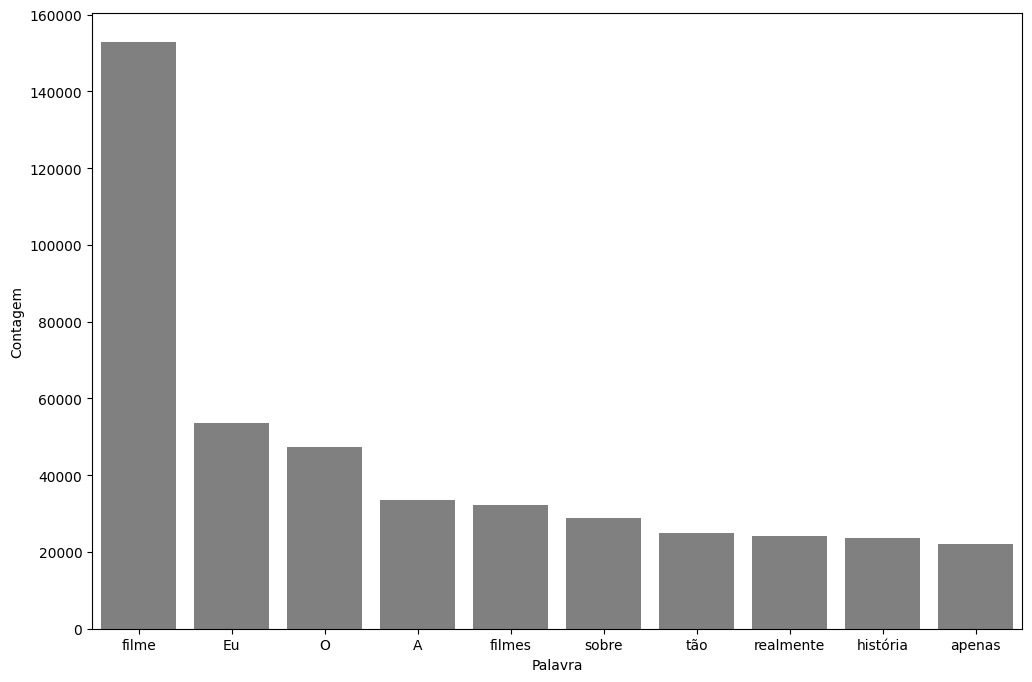

In [50]:
grafico_barras(resenhas, 'tratamento_stopwords_pontuacao', 10)

In [51]:
import unidecode

acentos = "ótimo péssimo não é tão"

teste = unidecode.unidecode(acentos)
print(teste)

otimo pessimo nao e tao


In [52]:
# retirando os acentos das palavras da base de dados tratada
sem_acentos = [unidecode.unidecode(texto) for texto in resenhas.tratamento_stopwords_pontuacao]

In [53]:
# retirando os acentos das stopwords, para que a filtragem seja feita de forma correta
stopwords_e_pontuacao_sem_acentos = [unidecode.unidecode(texto) for texto in stopwords_e_pontuacao] 

In [54]:
# retirando as stopwords da base de dados sem acentos
resenhas["tratamento_stopwords_pontuacao_sem_acentos"] = sem_acentos

frase_processada = list()
for opiniao in resenhas['tratamento_stopwords_pontuacao_sem_acentos']:
    nova_frase = list()
    palavras_texto = token_pontuacao.tokenize(opiniao) # separando a frase sem acentos em palavras ignorando a pontuação
    for palavra in palavras_texto:
        if palavra not in stopwords_e_pontuacao_sem_acentos:
            nova_frase.append(palavra)
    frase_processada.append(' '.join(nova_frase))


resenhas["tratamento_stopwords_pontuacao_sem_acentos"] = frase_processada

In [55]:
resenhas.head()

,id,text_en,text_pt,sentiment,classificacao,tratamento_stopwords,tratamento_stopwords_pontuacao,tratamento_stopwords_pontuacao_sem_acentos
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,0,"Mais vez, Sr. Costner arrumou filme tempo nece...",Mais vez Sr Costner arrumou filme tempo necess...,Mais vez Sr Costner arrumou filme tempo necess...
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,0,Este exemplo motivo maioria filmes ação mesmos...,Este exemplo motivo maioria filmes ação mesmos...,Este exemplo motivo maioria filmes acao mesmos...
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,0,"Primeiro tudo odeio raps imbecis, poderiam agi...",Primeiro tudo odeio raps imbecis poderiam agir...,Primeiro tudo odeio raps imbecis poderiam agir...
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,0,Nem Beatles puderam escrever músicas todos gos...,Nem Beatles puderam escrever músicas todos gos...,Nem Beatles puderam escrever musicas todos gos...
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,0,"Filmes fotos latão palavra apropriada eles, ve...",Filmes fotos latão palavra apropriada verdade ...,Filmes fotos latao palavra apropriada verdade ...


In [58]:
acuracia_tratamento_stopwords_pontuacao_sem_acentos = classificar_texto(resenhas, 'tratamento_stopwords_pontuacao_sem_acentos', 'classificacao')
print(acuracia_tratamento_stopwords_pontuacao_sem_acentos)

0.6887990295188031


In [59]:
# as stopwords já estão em minúsculas, agora eu preciso apenas de retirar novamente as stopwords da base de dados (que dessa vez está em minúscula)
# realizando um novo tratamento, desta vez transformando todas as palavras da base para minúsculas, para que palavras iguais sejam tratadas como iguais, mesmo que estejam em caixa alta ou baixa

frase_processada = list()
for opiniao in resenhas['tratamento_stopwords_pontuacao_sem_acentos']:
    nova_frase = list()
    opiniao.lower() # transformando a frase em minúscula
    palavras_texto = token_pontuacao.tokenize(opiniao) # separando a frase sem acentos em palavras ignorando a pontuação
    for palavra in palavras_texto:
        if palavra not in stopwords_e_pontuacao_sem_acentos:
            nova_frase.append(palavra)
    frase_processada.append(' '.join(nova_frase))

resenhas['tratamento_minusculas'] = frase_processada

In [60]:
resenhas.head()

,id,text_en,text_pt,sentiment,classificacao,tratamento_stopwords,tratamento_stopwords_pontuacao,tratamento_stopwords_pontuacao_sem_acentos,tratamento_minusculas
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,0,"Mais vez, Sr. Costner arrumou filme tempo nece...",Mais vez Sr Costner arrumou filme tempo necess...,Mais vez Sr Costner arrumou filme tempo necess...,Mais vez Sr Costner arrumou filme tempo necess...
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,0,Este exemplo motivo maioria filmes ação mesmos...,Este exemplo motivo maioria filmes ação mesmos...,Este exemplo motivo maioria filmes acao mesmos...,Este exemplo motivo maioria filmes acao mesmos...
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,0,"Primeiro tudo odeio raps imbecis, poderiam agi...",Primeiro tudo odeio raps imbecis poderiam agir...,Primeiro tudo odeio raps imbecis poderiam agir...,Primeiro tudo odeio raps imbecis poderiam agir...
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,0,Nem Beatles puderam escrever músicas todos gos...,Nem Beatles puderam escrever músicas todos gos...,Nem Beatles puderam escrever musicas todos gos...,Nem Beatles puderam escrever musicas todos gos...
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,0,"Filmes fotos latão palavra apropriada eles, ve...",Filmes fotos latão palavra apropriada verdade ...,Filmes fotos latao palavra apropriada verdade ...,Filmes fotos latao palavra apropriada verdade ...


In [61]:
acuracia_minusculas = classificar_texto(resenhas, "tratamento_stopwords_pontuacao_sem_acentos", "classificacao")
print(acuracia_minusculas)

0.6887990295188031


#### utilizaremos stemmer inicialmente para tratar as flexões e derivações nas palavras

In [62]:
# utilizaremos stemmer para chegar na raiz das palavras
stemmer = nltk.RSLPStemmer()
print(stemmer.stem("corredor"))
print(stemmer.stem("correndo"))
print(stemmer.stem("correu"))


corr
corr
corr


In [67]:
# aplicando stemmer na base de dados, para reduzir as palavras à sua raiz e diminuir a dimensionalidade do modelo
frase_processada = list()
for opiniao in resenhas['tratamento_stopwords_pontuacao_sem_acentos']:
    nova_frase = list()
    palavras_texto = token_pontuacao.tokenize(opiniao)
    for palavra in palavras_texto:
        raiz_palavra = stemmer.stem(palavra)
        nova_frase.append(raiz_palavra)
    frase_processada.append(' '.join(nova_frase))

resenhas['tratamento_stemmer'] = frase_processada

In [66]:
resenhas.head()

,id,text_en,text_pt,sentiment,classificacao,tratamento_stopwords,tratamento_stopwords_pontuacao,tratamento_stopwords_pontuacao_sem_acentos,tratamento_minusculas,tratamento_stemmer
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,0,"Mais vez, Sr. Costner arrumou filme tempo nece...",Mais vez Sr Costner arrumou filme tempo necess...,Mais vez Sr Costner arrumou filme tempo necess...,Mais vez Sr Costner arrumou filme tempo necess...,mais vez sr costn arrum film temp necessari al...
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,0,Este exemplo motivo maioria filmes ação mesmos...,Este exemplo motivo maioria filmes ação mesmos...,Este exemplo motivo maioria filmes acao mesmos...,Este exemplo motivo maioria filmes acao mesmos...,est exempl motiv maior film aca mesm gener cha...
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,0,"Primeiro tudo odeio raps imbecis, poderiam agi...",Primeiro tudo odeio raps imbecis poderiam agir...,Primeiro tudo odeio raps imbecis poderiam agir...,Primeiro tudo odeio raps imbecis poderiam agir...,prim tud odei rap imbecil pod agir arm pressio...
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,0,Nem Beatles puderam escrever músicas todos gos...,Nem Beatles puderam escrever músicas todos gos...,Nem Beatles puderam escrever musicas todos gos...,Nem Beatles puderam escrever musicas todos gos...,nem beatl pud escrev music tod gost emb walt h...
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,0,"Filmes fotos latão palavra apropriada eles, ve...",Filmes fotos latão palavra apropriada verdade ...,Filmes fotos latao palavra apropriada verdade ...,Filmes fotos latao palavra apropriada verdade ...,film fot lata palavr apropri verdad tant ous s...


In [68]:
acuracia_stemmer = classificar_texto(resenhas, "tratamento_stemmer", "classificacao")

In [69]:
print(acuracia_stemmer)

0.6707642539425799


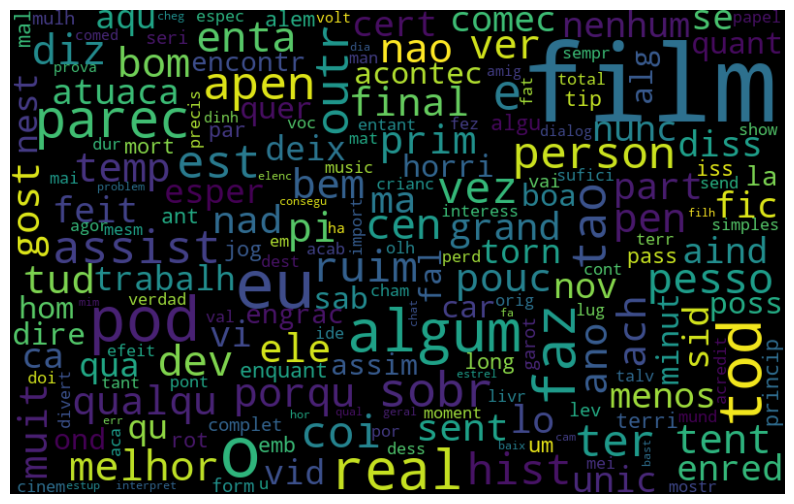

In [73]:
nuvem_palavras_neg(resenhas, "tratamento_stemmer")

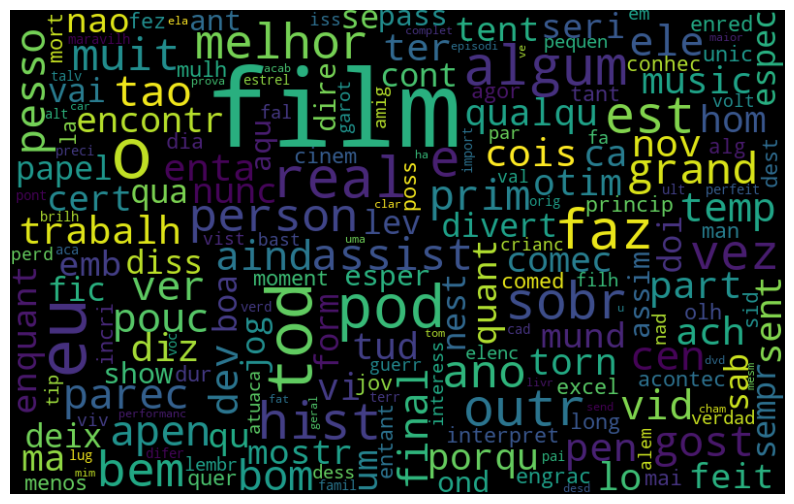

In [74]:
nuvem_palavras_pos(resenhas, "tratamento_stemmer")

#### Agora, utilizaremos lematização (lemmatization) para identificar palavras similares (file/filmes) e reduzirmos o dataset às palavras iniciais

In [ ]:
# é necessário baixar a biblioteca antes via terminal (!python -m spacy download pt_core_news_sm)
import spacy 

In [ ]:
nlp = spacy.load('pt_core_news_sm')

In [ ]:
# Process some text
text = "Acabei de assistir à palestra sobre Inteligência Artificial!"
doc = nlp(text)

# Example: Print tokens and their part-of-speech tags
for token in doc:
    print(f"Token: {token.text}, POS Tag: {token.pos_}, Dependency: {token.dep_}")

# Example: Print named entities
for ent in doc.ents:
    print(f"Entity: {ent.text}, Label: {ent.label_}")

Token: Acabei, POS Tag: PROPN, Dependency: ROOT
Token: de, POS Tag: SCONJ, Dependency: mark
Token: assistir, POS Tag: VERB, Dependency: acl
Token: à, POS Tag: ADP, Dependency: case
Token: palestra, POS Tag: NOUN, Dependency: obj
Token: sobre, POS Tag: ADP, Dependency: case
Token: Inteligência, POS Tag: PROPN, Dependency: nmod
Token: Artificial, POS Tag: PROPN, Dependency: flat:name
Token: !, POS Tag: PUNCT, Dependency: punct
Entity: Inteligência Artificial, Label: MISC
